# Particle stress test on W — boundaries

Minimal replication of `MERCATOR_parcels_UWV.ipynb`: same fieldset, same C-grid settings, same
`CheckError` kernel, same `chunks` on the ParticleFile. Two additions:

1. Particles are released **at every boundary**, not only in the plume — surface, seabed,
   coast, and the domain rim — so we can see which boundary each field survives.
2. It runs twice on identical seeds, once with the raw GLORYS files and once with the
   Poisson-corrected `*_1993-01b.nc`, and the outcomes are compared.

January 1993 only. Particles that error are deleted, exactly as in `MERCATOR_parcels_UWV`, so
a particle's fate is read off the end of its track: where it stopped, when, and how deep.

In [16]:
# ---------------- run configuration ----------------
n_per_group        = 60         # particles in each of the 5 release groups
run_time_days      = 10
time_step_minutes  = 10
out_put_step_hours = 6

ref_date = "1993-01-01"
offset   = 1                    # release on 1993-01-02
rdm_seed = 110987

Hgr = "Hgr_cmesh.nc"
Zgr = "Zgr_cmesh2.nc"

EXPERIMENTS = {
    "glorys":    dict(U="U_1993-01.nc",  V="V_1993-01.nc",  W="W_1993-01.nc"),
    "poisson_b": dict(U="U_1993-01b.nc", V="V_1993-01b.nc", W="W_1993-01b.nc"),
}

# the MERCATOR_parcels release line, for the "plume" and "surface" groups
lon0, lon1 =  -49.916, -49.083
lat0, lat1 =    1.166,  -0.0833

out_root = "stress_tracks"

In [17]:
import os, sys, shutil, contextlib
import numpy as np
import xarray as xr
from datetime import timedelta

from parcels import FieldSet, ParticleSet, JITParticle, Variable, AdvectionRK4_3D

@contextlib.contextmanager
def quiet():
    """Silence the compiled kernel's stdout (cell-search debug dumps). tqdm uses stderr."""
    sys.stdout.flush()
    saved, devnull = os.dup(1), os.open(os.devnull, os.O_WRONLY)
    try:
        os.dup2(devnull, 1)
        yield
    finally:
        os.dup2(saved, 1); os.close(devnull); os.close(saved)


start_time = np.datetime64(ref_date) + np.timedelta64(offset, "D")
print("release", start_time, "| parcels", __import__("parcels").__version__)

release 1993-01-02 | parcels 3.1.2


## 1. Where the boundaries are

In [18]:
zgr = xr.open_dataset(Zgr).squeeze()
mbathy  = zgr.mbathy.values.astype(int)
gdepw_0 = zgr.gdepw_0.squeeze().values.astype("f8")
lon2d, lat2d = zgr.nav_lon.values, zgr.nav_lat.values
ny, nx = mbathy.shape

H = np.where(mbathy > 0, gdepw_0[np.clip(mbathy, 0, len(gdepw_0) - 1)], 0.0)   # seabed depth
box = (lon2d > -52) & (lon2d < -46) & (lat2d > -1.5) & (lat2d < 4.5)           # plume box
print(f"domain {ny} x {nx};  plume box has {int((box & (mbathy>0)).sum())} wet columns, "
      f"depths {H[box & (mbathy>0)].min():.0f}-{H[box & (mbathy>0)].max():.0f} m")

domain 499 x 1260;  plume box has 3411 wet columns, depths 7-3792 m


In [19]:
rng = np.random.default_rng(rdm_seed)

def pick(mask, n):
    '''n random (lon, lat, H) triples from the wet columns selected by `mask`.'''
    j, i = np.where(mask)
    k = rng.choice(len(j), size=n, replace=len(j) < n)
    return lon2d[j[k], i[k]], lat2d[j[k], i[k]], H[j[k], i[k]]

groups = {}

# plume   - the MERCATOR release line, 0-10 m. The baseline case.
s = rng.uniform(0, 1, n_per_group)
groups["plume"] = (lon0 + s * (lon1 - lon0), lat0 + s * (lat1 - lat0),
                   rng.uniform(0, 10, n_per_group))

# surface - same line, pressed against the top boundary
s = rng.uniform(0, 1, n_per_group)
groups["surface"] = (lon0 + s * (lon1 - lon0), lat0 + s * (lat1 - lat0),
                     rng.uniform(0.05, 0.5, n_per_group))

# seabed  - shelf columns, 95% of the way down to the bottom
lo, la, hh = pick(box & (H > 20) & (H < 80), n_per_group)
groups["seabed"] = (lo, la, 0.95 * hh)

# coast   - the shallowest wet cells, right against the land mask
lo, la, hh = pick(box & (mbathy > 0) & (H < 15), n_per_group)
groups["coast"] = (lo, la, 0.5 * hh)

GROUP_NAMES = list(groups)
start_lon   = np.concatenate([groups[g][0] for g in GROUP_NAMES])
start_lat   = np.concatenate([groups[g][1] for g in GROUP_NAMES])
start_depth = np.concatenate([groups[g][2] for g in GROUP_NAMES])
start_grp   = np.concatenate([np.full(n_per_group, k) for k in range(len(GROUP_NAMES))])
num_particles = len(start_lon)

for k, g in enumerate(GROUP_NAMES):
    d = groups[g][2]
    print(f"  {k} {g:<8s} n={n_per_group:3d}  release depth {d.min():7.2f} - {d.max():7.2f} m")

  0 plume    n= 60  release depth    0.09 -   10.00 m
  1 surface  n= 60  release depth    0.06 -    0.49 m
  2 seabed   n= 60  release depth   22.17 -   67.98 m
  3 coast    n= 60  release depth    3.58 -    7.30 m


## 2. Fieldset — as in MERCATOR_parcels_UWV

In [20]:
def make_fieldset(ufiles, vfiles, wfiles):
    filenames = {
        "U": {"data": ufiles, "lon": Hgr, "lat": Hgr, "depth": wfiles},
        "V": {"data": vfiles, "lon": Hgr, "lat": Hgr, "depth": wfiles},
        "W": {"data": wfiles, "lon": Hgr, "lat": Hgr, "depth": wfiles},
    }
    variables = {"U": "vozocrtx", "V": "vomecrty", "W": "vovecrtz"}
    interp_method = {"U": "cgrid_velocity", "V": "cgrid_velocity", "W": "cgrid_velocity"}
    dimensions = {v: {"lon": "glamf", "lat": "gphif", "depth": "depthw",
                      "time": "time_counter"} for v in variables}
    return FieldSet.from_netcdf(
        filenames, variables, dimensions,
        interp_method=interp_method,
        deferred_load=True,
        allow_time_extrapolation=False,
        gridindexingtype="nemo",
    )

## 3. Particle and kernels

In [21]:
class StressParticle(JITParticle):
    grp  = Variable("grp",  initial=0,     dtype=np.int32, to_write="once")
    zmin = Variable("zmin", initial=1e10,  dtype=np.float32)
    zmax = Variable("zmax", initial=-1e10, dtype=np.float32)


def TrackDepth(particle, fieldset, time):
    if particle.depth < particle.zmin:
        particle.zmin = particle.depth
    if particle.depth > particle.zmax:
        particle.zmax = particle.depth


def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

## 4. Run both experiments

In [22]:
def run(tag, files):
    out_dir = os.path.join(out_root, f"{tag}.zarr")
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)                      # our own output from a previous run
    os.makedirs(out_root, exist_ok=True)

    fieldset = make_fieldset(files["U"], files["V"], files["W"])
    pset = ParticleSet(fieldset=fieldset, pclass=StressParticle,
                       lon=start_lon, lat=start_lat, depth=start_depth,
                       time=np.datetime64(start_time), grp=start_grp)
    pfile = pset.ParticleFile(
        name=out_dir,
        outputdt=timedelta(hours=out_put_step_hours),
        chunks=(num_particles, int(run_time_days * 24 / out_put_step_hours / 4)),
    )
    with quiet():
        pset.execute([AdvectionRK4_3D, TrackDepth, CheckError],
                     runtime=timedelta(days=run_time_days),
                     dt=timedelta(minutes=time_step_minutes),
                     output_file=pfile)
    return out_dir

paths = {}
for tag, files in EXPERIMENTS.items():
    print(f"\n===== {tag} =====")
    paths[tag] = run(tag, files)
print("\ndone:", paths)


===== glorys =====


/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vovecrtz' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vozocrtx' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vovecrtz' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vomecrty

INFO: Output files are stored in stress_tracks/glorys.zarr.
  0%|          | 0/864000.0 [00:00<?, ?it/s]

/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vozocrtx' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vozocrtx' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vomecrty' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vomecrty

  2%|▎         | 21600.0/864000.0 [00:07<03:32, 3968.72it/s]

...

 82%|████████▎ | 712800.0/864000.0 [01:13<00:12, 12087.76it/s]

/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vozocrtx' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vomecrty' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vovecrtz' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


 92%|█████████▎| 799200.0/864000.0 [01:21<00:04, 13774.97it/s]

/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vozocrtx' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vomecrty' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vovecrtz' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


100%|██████████| 864000.0/864000.0 [01:27<00:00, 9870.55it/s] 

===== poisson_b =====
 70%|███████   | 605400.0/864000.0 [15:36<06:40, 646.23it/s]  
INFO: Output files are stored in stress_tracks/poisson_b.zarr.
100%|██████████| 864000.0/864000.0 [00:59<00:00, 14506.60it/s]

done: {'glorys': 'stress_tracks/glorys.zarr', 'poisson_b': 'stress_tracks/poisson_b.zarr'}


## 5. Compare

A particle that errored was deleted, so its track simply stops. Its fate is read off the last
valid observation: when it stopped, where, and at what depth.

In [23]:
res = {tag: xr.open_zarr(p).compute() for tag, p in paths.items()}

def summarise(ds):
    lat = ds.lat.values
    z   = ds.z.values
    valid = np.isfinite(lat)
    nobs  = valid.sum(axis=1)                       # number of observations before it stopped
    last  = np.where(nobs > 0, nobs - 1, 0)
    r     = np.arange(len(nobs))
    return dict(
        grp    = ds.grp.values,
        alive  = nobs == valid.shape[1],            # survived the whole run
        t_lost = nobs * out_put_step_hours / 24.0,  # days before it stopped
        z_last = np.where(nobs > 0, z[r, last], np.nan),
        z_max  = np.nanmax(np.where(valid, z, np.nan), axis=1),
        z_min  = np.nanmin(np.where(valid, z, np.nan), axis=1),
    )

S = {t: summarise(d) for t, d in res.items()}

hdr = f"{'group':<9}" + "".join(f"{t:<38}" for t in S)
print(hdr)
print(f"{'':<9}" + "".join(f"{'alive':>7}{'lost':>6}{'t_lost':>8}{'z_max':>8}{'z_min':>9}" for t in S))
for k, g in enumerate(GROUP_NAMES):
    line = f"{g:<9}"
    for t, s in S.items():
        m = s["grp"] == k
        lost = ~s["alive"][m]
        line += (f"{int(s['alive'][m].sum()):>7}{int(lost.sum()):>6}"
                 f"{(np.median(s['t_lost'][m][lost]) if lost.any() else np.nan):>8.1f}"
                 f"{np.nanmax(s['z_max'][m]):>8.1f}{np.nanmin(s['z_min'][m]):>9.3f}")
    print(line)
print("\nalive = finished the run;  lost = deleted on error;  t_lost = median days until deleted")
print("z_max = deepest reached [m];  z_min = shallowest reached [m], negative is above the surface")

group    glorys                                poisson_b                             
           alive  lost  t_lost   z_max    z_min  alive  lost  t_lost   z_max    z_min
plume         41    19     5.0    16.1    0.000     60     0     nan    15.4    0.004
surface        0    60     1.5     0.6    0.000     60     0     nan     8.6    0.004
seabed        60     0     nan    87.2    2.758     60     0     nan    96.2    6.388
coast         52     8     7.2    16.6    0.000     60     0     nan    18.4    0.008

alive = finished the run;  lost = deleted on error;  t_lost = median days until deleted
z_max = deepest reached [m];  z_min = shallowest reached [m], negative is above the surface


## 6. Plots

/var/folders/s1/62z527j141g8f5z22f9vb42d44rbwm/T/ipykernel_2148/3272085984.py:15: RuntimeWarning: All-NaN slice encountered
  ax.plot(t, np.nanmedian(z, axis=0), lw=2, color=COL[tag], label=tag, zorder=3)
/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


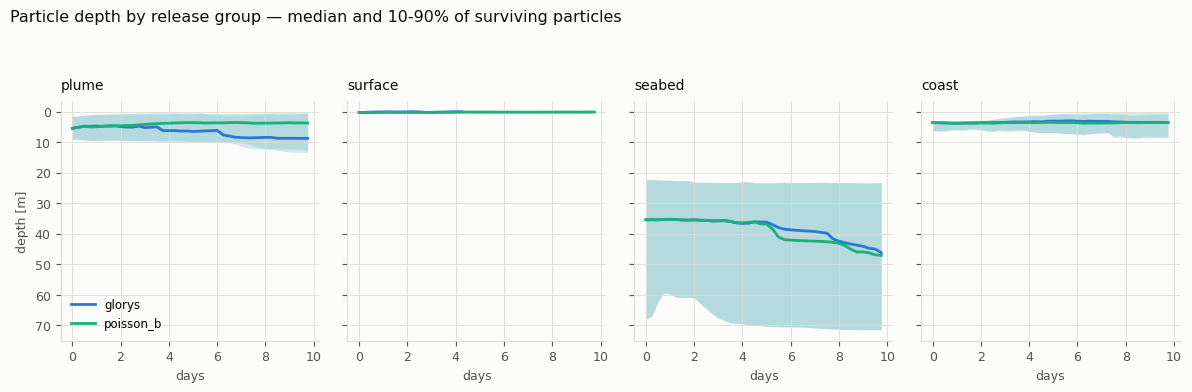

In [24]:
import matplotlib.pyplot as plt

SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dedcd6"
COL = {"glorys": "#2a78d6", "poisson_b": "#1baf7a"}
plt.rcParams.update({"font.size": 9, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.facecolor": SURF,
    "figure.facecolor": SURF, "axes.titlecolor": INK})

fig, axs = plt.subplots(1, len(GROUP_NAMES), figsize=(3.0 * len(GROUP_NAMES), 3.9), sharey=True)
for k, (g, ax) in enumerate(zip(GROUP_NAMES, axs)):
    for tag, ds in res.items():
        m = ds.grp.values == k
        z = np.where(np.isfinite(ds.lat.values[m]), ds.z.values[m], np.nan)
        t = np.arange(z.shape[1]) * out_put_step_hours / 24.0
        ax.plot(t, np.nanmedian(z, axis=0), lw=2, color=COL[tag], label=tag, zorder=3)
        ax.fill_between(t, np.nanpercentile(z, 10, axis=0), np.nanpercentile(z, 90, axis=0),
                        color=COL[tag], alpha=0.18, lw=0)
    ax.set_title(g, loc="left", fontsize=10, pad=8)
    ax.set_xlabel("days")
    ax.grid(True, lw=0.6, color=GRID)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
axs[0].set_ylabel("depth [m]")
axs[0].invert_yaxis()
axs[0].legend(frameon=False, fontsize=8.5, loc="best")
fig.suptitle("Particle depth by release group — median and 10-90% of surviving particles",
             x=0.006, ha="left", fontsize=11.5, color=INK, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("stress_depth_by_group.png", dpi=170, facecolor=SURF)
plt.show()

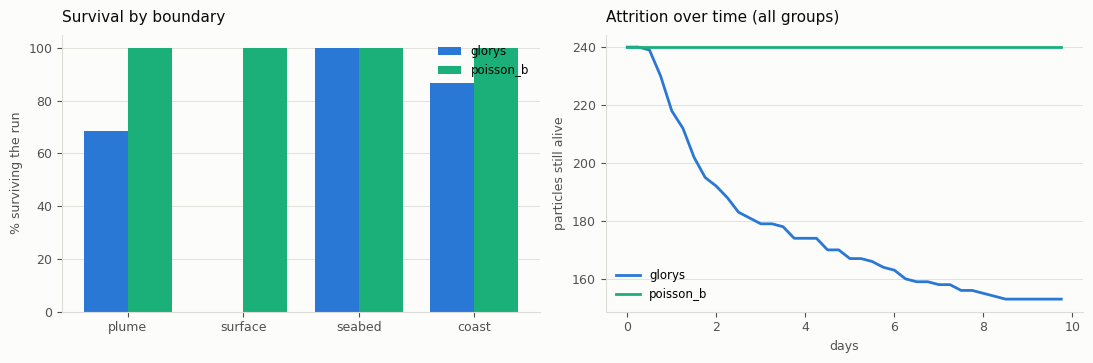

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.7))
w = 0.38
x = np.arange(len(GROUP_NAMES))

for n, (tag, s) in enumerate(S.items()):
    surv = [100 * s["alive"][s["grp"] == k].mean() for k in range(len(GROUP_NAMES))]
    axs[0].bar(x + (n - 0.5) * w, surv, w, color=COL[tag], label=tag)
axs[0].set_ylabel("% surviving the run"); axs[0].set_ylim(0, 105)
axs[0].set_title("Survival by boundary", loc="left", fontsize=11, pad=9)

for n, (tag, ds) in enumerate(res.items()):
    nvalid = np.isfinite(ds.lat.values).sum(axis=0)
    t = np.arange(len(nvalid)) * out_put_step_hours / 24.0
    axs[1].plot(t, nvalid, lw=2, color=COL[tag], label=tag)
axs[1].set_xlabel("days"); axs[1].set_ylabel("particles still alive")
axs[1].set_title("Attrition over time (all groups)", loc="left", fontsize=11, pad=9)

axs[0].set_xticks(x); axs[0].set_xticklabels(GROUP_NAMES)
for ax in axs:
    ax.grid(True, axis="y", lw=0.6, color=GRID); ax.set_axisbelow(True)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    ax.legend(frameon=False, fontsize=8.5)
fig.tight_layout()
fig.savefig("stress_survival.png", dpi=170, facecolor=SURF)
plt.show()

---

**One caveat when reading the comparison.** The raw GLORYS files carry `NaN` over land and
below the seabed; the `*b.nc` files carry `0`, because that is how the Poisson notebook writes
them. That difference is not part of the Poisson correction, and it affects the `coast` and
`seabed` groups on its own. If the two experiments differ mainly in those two groups, check the
fill convention before crediting the correction.